![logo](../../../LogoLine_horizon_C3S.png)

<div class="alert alert-block alert-warning">
Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch
</div>

# Consistency of ozone mixing ratio from limb, nadir, and in situ measurements  

Production date: 20-07-2025

Produced by: Chiara Volta (ENEA, Italy) and Sandro Calmanti (ENEA, Italy)

## 🌍 Use case: Support policy in detecting large ozone depletion events.

## ❓ Quality assessment questions

* **How well do limb and nadir satellite datasets agree with ozonesondes in monitoring stratospheric ozone mixing ratio in high-latitude regions?**
* **Can differences between limb and nadir measurements affect the interpretation of ozone depletion events for policymaking?**

Stratospheric ozone plays a vital role in protecting life on Earth from harmful solar ultraviolet radiation, and assessing its return to historical levels and its full recovery from ozone-depleting substances (ODS) is a critical objective [[1]](https://doi.org/10.1007/s43630-023-00371-y). Since the adoption of the 1987 Montreal Protocol, the international scientific community has been tasked with providing governments with regular updates on the state of the ozone layer and guidance for strengthening the Protocol's provisions. In this context, the availability of high-quality ozone observations is essential for monitoring trends, evaluating the effectiveness of policy measures, and supporting robust scientific assessments.

The goal of this assessment is to evaluate the consistency between ozone observations from limb- and nadir-viewing satellite sensors and *in situ* ozonesonde measurements of stratospheric ozone. Additionally, it aims to assess whether differences between limb and nadir data could influence the interpretation of ozone depletion events, with potential implication for the scientific advice that informs policy decisions.

A full description of ozone data from limb and nadir satellite sensors and derived datasets is provided in [[2]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2-FDDP-PUGS_202311_O3_v3.5_final.pdf). Ozonesonde data are freely available from the [World Ozone and Ultraviolet Radiation Centre (WOUDC)](https://woudc.org/en).

## 📢 Quality assessment statements

```{admonition} These are the key outcomes of this assessment
:class: note
* Both limb- and nadir-viewing satellite datasets effectively capture the seasonal variability of stratospheric ozone mixing ratios at mid- and high-latitudes.
* Satellite datasets demonstrate significantly higher agreement with ozonesondes at mid-to-high Northern latitudes than in the Antarctic region. 
* Despite the extended temporal coverage provided by successive satellite missions, inconsistencies between different versions of the same product and between products from similar sensor types (i.e., limb or nadir) limit their suitability for detecting long-term ozone trend in the stratospheric ozone layer.
* The consistency between satellite and *in situ* measurements depends on both the ozone concentration in the stratosphere and latitude.
* The tendency for satellites to overestimate ozone during depletion events at high Southern latitudes could lead to an underestimation of the severity of ozone depletion events. 
```

## 📋 Methodology

The analysis performed in this notebook focuses on comparing ozone mixing ratios measured by limb and nadir satellite sensors with *in situ* ozonesonde observations from two stations: Edmonton (EDT - Canada) and Marambio (MBI - Antarctica). These stations were selected due to the availability of long-term time series and can be considered as representative of mid- to high-latitude regions in the Northern and Southern Hemispheres, respectively. To evaluate consistency across datasets, time series from satellite and ozonesonde measurements were compared, and statistical indicators such as Root Mean Square Error (RMSE), Mean Bias Error (MBE), Mean Absolute Percentage Error (MAPE) and Standard Error (SE) were calculated.  
The analysis excludes merged satellite datasets (e.g., MSR and AMZM) to avoid potential inconsistencies related to cross-sensor averaging and algorithmic harmonization.

[](satellite_satellite-ozone-v1_consistency_q03:sec1)

* Import libraries
* Define data requests and other parameters
  
[](satellite_satellite-ozone-v1_consistency_q03:sec2)

* Define required functions
* Data retrieval

[](satellite_satellite-ozone-v1_consistency_q03:sec3)

* Define function to extract ozonesonde data
* Download ozonesonde data by station

[](satellite_satellite-ozone-v1_consistency_q03:sec4)

* Define statistical function

[](satellite_satellite-ozone-v1_consistency_q03:sec5)

* Display results
* Discussion

## 📈 Analysis and results

(satellite_satellite-ozone-v1_consistency_q03:sec1)=
### 1. Set up the code and choose the satellite data to use

#### Import libraries

Besides the standard libraries used to manage and analyse multidimensional arrays, the [C3S EQC custom function](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control) `c3s_eqc_automatic_quality_control` is imported to download satellite data and calculate their spatially weighted means. The `requests` module is imported to download ozonesonde data.

In [1]:
import os
import cdsapi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import requests
import xarray as xr
from c3s_eqc_automatic_quality_control import diagnostics, download
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-notebook")

#### Define data requests and other parameters

The analysis performed in this notebook focuses on ozone data from both limb and nadir satellite sensors [[2]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2-FDDP-PUGS_202311_O3_v3.5_final.pdf). Specifically, it uses limb and nadir data extracted over latitude bands centred on the ozonesonde station locations (see 'Download ozonesonde data by station' section below), at an atmospheric pressure level of 50 hPa. This pressure level, corresponding to an altitude of about 20 km, lies within the lower stratosphere and is commonly used to evaluate ozone profiles due to the high ozone concentrations typically found at this altitude [[3]](https://doi.org/10.1140/epjconf/e2009-00914-y).  

In [2]:
# Client configuration
os.environ["CDSAPI_RC"] = os.path.expanduser("~/calmanti_sandro/.cdsapirc")

# Latitudes
lat_slices = [slice(54.5, 55.5), slice(-65.5, -64.5)]

# Pressure level in hPa
pressure = 50

# Set satellite data requests
collection_id = "satellite-ozone-v1"
request_dict = {
    "limb": {
        "processing_level": "level_3",
        "variable": "mole_concentration_of_ozone_in_air",
        "vertical_aggregation": "vertical_profiles_from_limb_sensors",
    },
    "nadir": {
        "processing_level": "level_3",
        "variable": "mole_content_of_ozone_in_atmosphere_layer",
        "vertical_aggregation": "vertical_profiles_from_nadir_sensors",
    },
}

(satellite_satellite-ozone-v1_consistency_q03:sec2)=
### 2. Satellite data caching functions and retrieval
#### Define required functions 

The satellite datasets require the dedicated `preprocess` function to properly handle their time dimension.
While the nadir datasets directly provide ozone volume mixing ratio (i.e., mole fraction in ppv), the limb datasets require it to be calculated from ozone concentration (mol m$^{-3}$), along with the corresponding temperature (in K) and atmospheric pressure (in hPa). In this case, an ideal gas constant (rconst) of 8.314 J mol$^{-1}$ K$^{-1}$ is used. Moreover, while the limb data are already provided as zonal means, the nadir data must be spatially averaged.
Appropriate unit conversions are applied to express ozone mixing ratio in parts per million by volume (ppmv).  

In [3]:
def preprocess(ds):
    if "time" in ds.dims:
        return ds
    time_str = ds.attrs["time_coverage_start"][:6]
    time = pd.to_datetime(time_str, format="%Y%m")
    return ds.expand_dims(time=[time])

def compute_ozone_mixing_ratio(ds, lat_slices, pressure, rconst=8.314):
    # Select pressure
    if "pressure" in ds.dims:
        ds = ds.sel(pressure=pressure)
    else:
        ds = ds.where(ds["pressure"].notnull())
        diff = np.abs(ds["pressure"] - pressure).fillna(9999)
        ds = ds.isel(altitude=diff.argmin("altitude").compute())
    dataarrays = []
    for lat_slice in lat_slices:
        ds_lat = ds.sel(latitude=lat_slice)
        # Spatially weighted mean
        ds_lat = ds_lat.mean(
            set(ds_lat.dims) - {"time", "latitude", "longitude"},
            keep_attrs=True,
        )
        if ds_lat.sizes["latitude"] != 1:
            latitude = (
                ds_lat["latitude"].coarsen(latitude=ds_lat.sizes["latitude"]).mean()
            )
            ds_lat = diagnostics.spatial_weighted_mean(ds_lat)
            ds_lat = ds_lat.expand_dims(latitude=latitude)
            ds_lat["latitude"].attrs = latitude.attrs
        # Compute mixing ratio
        if "ozone_mixing_ratio" in ds_lat:
            da = ds_lat["ozone_mixing_ratio"] * 1.0e6 # convert volume mixing ratio (ppv) to ppmv
        else:
            da = (
                (ds_lat["ozone_concentration"] * rconst * ds_lat["temperature"])
                / ds_lat["pressure"]
            ) * 1e4 # compute and convert mole fraction to ppmv
        dataarrays.append(da.compute())
    da = xr.concat(dataarrays, "latitude")
    da.attrs = {"long_name": "O₃ mixing ratio", "units": "ppm"}
    return da.to_dataset(name="ozone_mixing_ratio")

def download_combined_dataset(collection_id, request):
    collection = cdsapi.Client(quiet=True).client.get_collection(collection_id)
    datasets = []
    for sensor in collection.apply_constraints(request)["sensor"]:
        if sensor in ["cllg", "cmzm", "merged_np", "gop_ecv", "megridop_conc"]:
            continue  # no merged products
        sensor_r = request | {"sensor": sensor}
        for algo in collection.apply_constraints(sensor_r)["algorithm"] or [None]:
            algo_r = sensor_r | {"algorithm": algo or []}
            for version in collection.apply_constraints(algo_r)["version"]:
                full_name = f"{sensor}_{version}"
                if "sage_cci_omps" in full_name and any(f"v000{i}" in full_name for i in range(1, 10)):   # no merged products
                    continue                    
                version_r = algo_r | {"version": version}
                request_list = []
                for year in collection.apply_constraints(version_r)["year"]:
                    year_r = version_r | {"year": year}
                    months = collection.apply_constraints(year_r)["month"]
                    request_list.append(year_r | {"month": months})
                product = "-".join([sensor, version] + ([algo] if algo else []))
                request_list = [
                    {k: v for k, v in r.items() if v != []} for r in request_list
                ]
                ds = download.download_and_transform(
                    collection_id,
                    request_list,
                    preprocess=preprocess,
                    transform_func=compute_ozone_mixing_ratio,
                    transform_func_kwargs={
                        "lat_slices": lat_slices,
                        "pressure": pressure,
                    },
                    quiet=True,
                )
                datasets.append(ds.expand_dims(product=[product]))
    return xr.concat(datasets, "product")

#### Data retrieval

Limb and nadir datasets are downloaded and combined into two separate datasets. For the limb data, only the most recent version of each sensor, which represents a temporal extension of the previous versions, is retained for the subsequent analysis [[4]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2_FDDP-PQAR_202311_O3_v3.3_final.pdf). In contrast, for the nadir data, multiple versions of the same instrument, such as GOME-2B, are retained because newer versions introduce new retrieval algorithms rather than extending the temporal coverage [[4]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2_FDDP-PQAR_202311_O3_v3.3_final.pdf). Keeping these versions together is therefore necessary to enable a comprehensive analysis and to provide a longer, continuous time series. Ultimately, a refined subset of 10 limb and 10 nadir datasets are selected for the final analysis.

In [4]:
datasets = {}
for sensor, request in request_dict.items():
    datasets[sensor] = download_combined_dataset(collection_id, request).compute()

# Datasets selection
selected_limb_products = [
    "ace-v0003", 
    "gomos-v0001", 
    "mipas-v0002", 
    "omps-v0002-ubr", 
    "omps-v0003-usask", 
    "osiris-v0003", 
    "sage_2-v0001", 
    "sage_3-v0002", 
    "sciamachy-v0001", 
    "smr-v0001"
]
selected_nadir_products = [
    "gome-v0006", 
    "gome2_a-v0006", 
    "gome2_a-v0007", 
    "gome2_b-v0006",
    "gome2_b-v0007",
    "gome2_b-v0008",
    "gome2_b-v0009", 
    "omi-v0006", 
    "omi-v0007", 
    "sciamachy-v0006"
]
filtered_datasets = {}
filtered_datasets['limb'] = datasets['limb'].sel(product=selected_limb_products)
filtered_datasets['nadir'] = datasets['nadir'].sel(product=selected_nadir_products)

(satellite_satellite-ozone-v1_consistency_q03:sec3)=
### 3. Download external ozonesonde data

Ozonesonde data are retrieved from the [World Ozone and Ultraviolet Radiation Centre (WOUDC)](https://woudc.org/en).

#### Define function to extract ozonesonde data

The `get_station` function is implemented to retrieve *in situ* ozone partial pressure (mPa) and atmospheric pressure (hPa) data from the WOUDC database. Only data at a pressure level of about 50 hPa are extracted. Ozonesonde data are combined to calculate the ozone mixing ratio (ppmv), which is then averaged monthly.

In [5]:
def get_station(station_gaw_id, pressure):
    dataarrays = []
    offset = 0
    page_size = 100
    while True:
        response = requests.get(
            "https://api.woudc.org/collections/ozonesonde/items",
            params={
                "station_gaw_id": station_gaw_id,
                "f": "json",
                "limit": page_size,
                "offset": offset,
            },
        )
        response.raise_for_status()
        data = response.json()
        features = data["features"]
        if len(features) == 0:
            break
        for feature in features:
            props = feature["properties"]
            pressure_profile = np.asarray(
                props["pressure"],
                dtype=float,
            )
            o3_profile = np.asarray(
                [
                    np.nan if x is None else float(x)
                    for x in props["o3partialpressure"]
                ],
                dtype=float,
            )
            idx = np.where(pressure_profile == pressure)[0]
            if len(idx) == 0:
                continue
            ozone = np.nanmean(o3_profile[idx])
            if np.isnan(ozone):
                continue
            time = pd.to_datetime(
                props["timestamp_date"]
            ).tz_localize(None)
            da = xr.DataArray(
                [ozone],
                dims=["time"],
                coords={"time": [time]},
            )
            dataarrays.append(da)
        offset += page_size
    da = xr.concat(dataarrays, dim="time")
    da = da.sortby("time")
    da = (da / pressure) * 10 # convert mole fraction to ppmv
    da = da.resample(time="1MS").mean()
    da = da.sel(time=slice("1985-10-01", None))
    da.attrs["long_name"] = "Ozone mixing ratio"
    da.attrs["units"] = "ppmv"
    return da.rename("ozone_mixing_ratio")

pressure = 50.0

#### Download ozonesonde data by station

Ozonesonde data are downloaded as single array from two stations: Edmonton (EDT) and Marambio (MBI). The EDT station is located in Canada (lat 53.55°N, lon 114.09°W) and represents mid- to subpolar latitudes in the Northern Hemisphere, while MBI station is in Antarctica (lat 64.24°S, lon 56.62°W) and represents high southern latitudes (see map below). Among the mid- and high-latitude stations in the WOUDC database, these two offer the longest time series available. More information can be found on the [WOUDC](https://woudc.org/en) website.

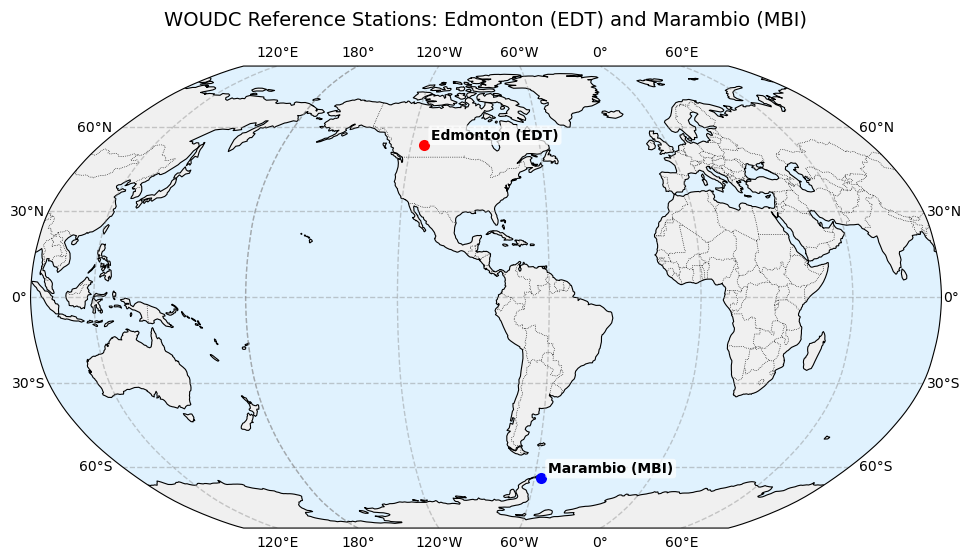

In [10]:
stations = ["EDT", "MBI"]
da_station = xr.concat(
    [
        get_station(station, pressure).expand_dims(station=[station])
        for station in stations
    ],
    dim="station",
)
# Display WOUDC stations map
stations_meta = {
    "Edmonton (EDT)": {"lat": 53.55, "lon": -114.09, "color": "red"},
    "Marambio (MBI)": {"lat": -64.24, "lon": -56.62, "color": "blue"}
}
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=-85))
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f2fe')
gl = ax.gridlines(draw_labels=True, dms=True, color='gray', alpha=0.4, linestyle='--')
gl.top_labels = True 
gl.right_labels = True 
for name, coords in stations_meta.items():
    ax.plot(coords["lon"], coords["lat"], 
            marker='o', color=coords["color"], markersize=8, 
            transform=ccrs.Geodetic(), label=name)
    ax.text(coords["lon"] + 3, coords["lat"] + 2, name, 
            transform=ccrs.Geodetic(), fontsize=10, weight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))
ax.set_global()
plt.title("WOUDC Reference Stations: Edmonton (EDT) and Marambio (MBI)", fontsize=14, pad=15)
plt.show()

(satellite_satellite-ozone-v1_consistency_q03:sec4)=
### 4. Compute statistics
#### Define statistical function

The `compute_statistics` function is implemented to calculate the Root Mean Square Error (RMSE), Mean Bias Error (MBE), Mean Absolute Percentage Error (MAPE) and Standard Error (SE) between ozone monthly mixing ratios from limb and nadir datasets and *in situ* ozonesonde observations.

In [11]:
def compute_statistics(reference, comparison):
    mean_dims = ["product", "time"]
    diff = comparison - reference
    rmse = np.sqrt((diff**2).groupby(ds["sensor"]).mean(mean_dims)) #Root Mean Squared Error
    mbe = diff.groupby(ds["sensor"]).mean(mean_dims) #Mean bias error
    mape = np.abs(diff / reference).groupby(ds["sensor"]).mean(mean_dims) * 100 #Mean Absolute Percentage Error
    se = (diff.groupby(ds["sensor"]).std(mean_dims))/(np.sqrt(diff.groupby(ds["sensor"]).count(mean_dims))) #Standard Error
    dataarrays = [rmse.rename("RMSE"), mbe.rename("MBE"), mape.rename("MAPE"), se.rename("SE")]
    return xr.merge(dataarrays).to_pandas()

(satellite_satellite-ozone-v1_consistency_q03:sec5)=
### 5. Display and discuss results
#### Display results

Monthly time series are displayed to compare satellite-derived ozone mixing ratios against ozonesonde measurements at two representative latitudes corresponding to the EDT (55°N) and MBI (65°S) stations. The satellite datasets are grouped by geometry: limb-viewing sensors in the upper panels and nadir-viewing in the lower panels. Each colored lines represent a satellite product, while the black line corresponds to ozonesonde data.
For each station, a scatter plot comparing monthly limb and nadir ozone mixing ratios (in red and green, respectively) with ozonesonde data is also presented, with statistical metrics indicated in the legend. The statistical analysis is performed by excluding monthly data before year 2002 due to the high discontinuity in both satellite and ozonesonde measurements. Dashed black 1:1 line in the scatter plots indicates perfect agreement between satellite and ozonesonde ozone mixing ratios.

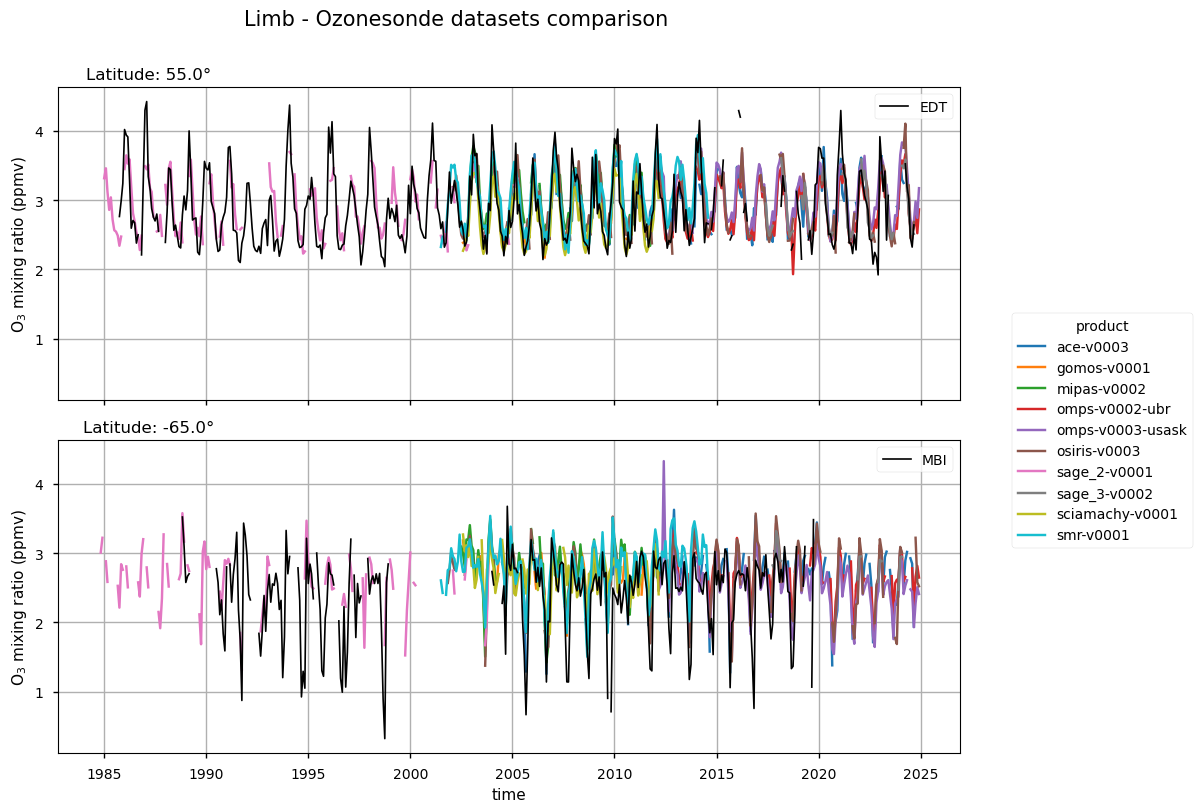

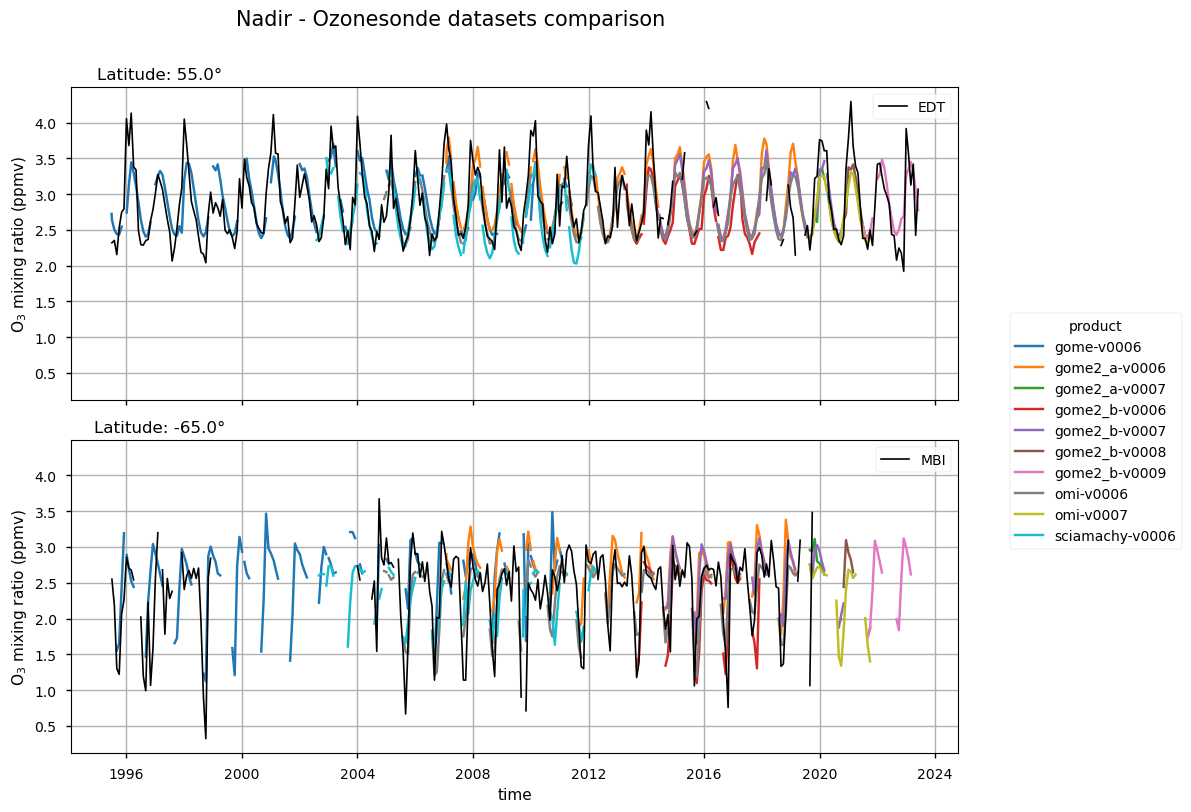

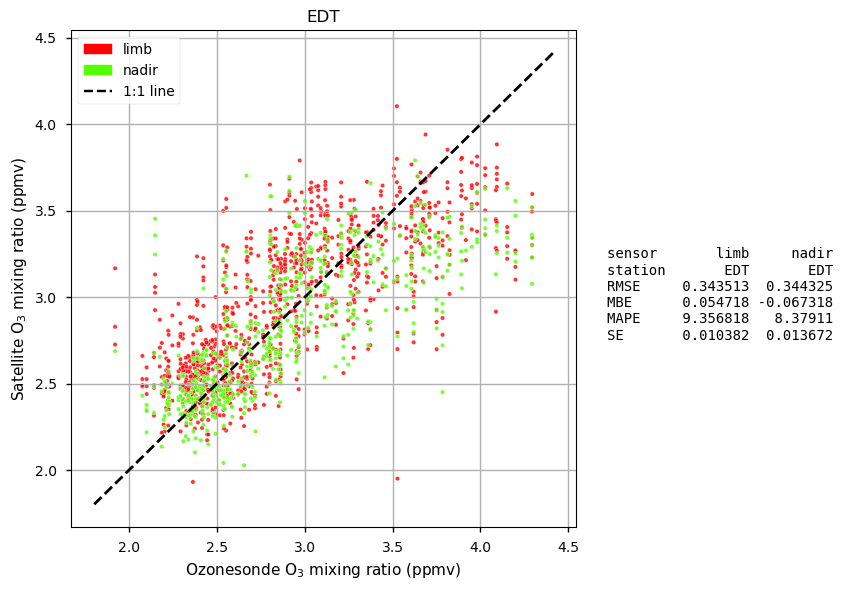

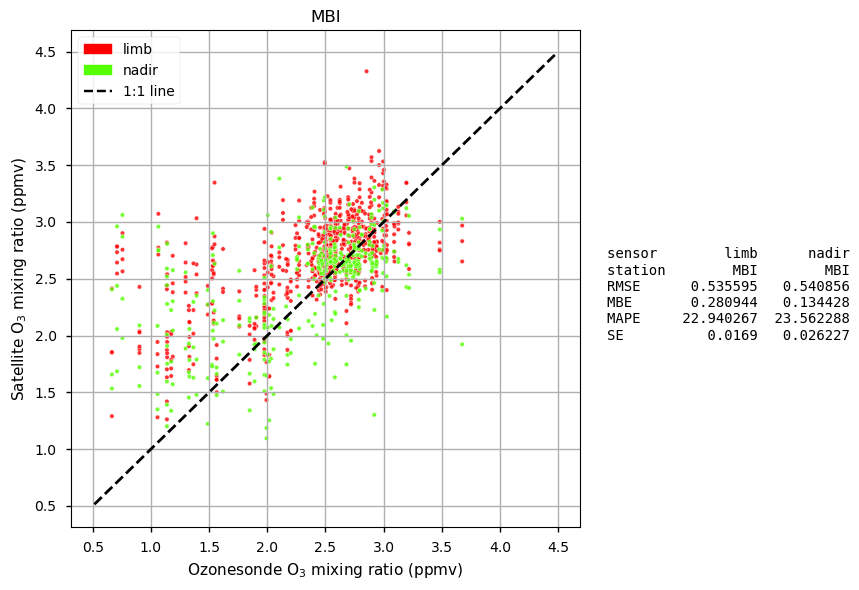

In [17]:
# Display ozonesonde and satellite data time series
stations = {
    55: "EDT",
    -65: "MBI",
}
for sensor, ds in filtered_datasets.items():
    (da,) = ds.data_vars.values()
    da = da.dropna(dim="product", how="all")
    da = da.sel(latitude=[55, -65])
    da_station_cutout = da_station.sel(
        time=slice(
            da.time.min().values,
            da.time.max().values,
        )
    )
    cmap = plt.get_cmap("tab10", da.sizes["product"])
    colors = [cmap(i) for i in range(da.sizes["product"])]
    with plt.rc_context({"axes.prop_cycle": plt.cycler(color=colors)}):
        facet = da.plot(
            row="latitude",
            hue="product",
            figsize=(10, 8),
            add_legend=False,
        )
    for ax, sel_dict in zip(facet.axs.flatten(), facet.name_dicts.flatten()):
        latitude = sel_dict["latitude"]
        station = stations[latitude]
        ax.plot(
            da_station_cutout.time,
            da_station_cutout.sel(station=station),
            color="black",
            linewidth=1.2,
            label=station,
            zorder=10,
        )
        ax.grid(True)
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles=handles[-1:], 
            labels=labels[-1:],
            loc="upper right",
            frameon=True,
        )
        ax.set_title(f"Latitude: {latitude}°", x=0.1, fontsize=12)
        ax.set_ylabel("O$_3$ mixing ratio (ppmv)")
    facet.fig.suptitle(
        f"{sensor.capitalize()} - Ozonesonde datasets comparison",
        y=1.01,
        x=0.4,
        fontsize=15,
    )
    plt.tight_layout()
    plt.subplots_adjust(right=0.80) 
    top_axis = facet.axs[0, 0]    
    facet.add_legend(
        loc="upper left",
        bbox_to_anchor=(1.05, 0.3),
        bbox_transform=top_axis.transAxes,
        frameon=True
    )
    plt.show()

# Display scatter plots and statistics
for latitude, station in stations.items():
    fig, ax = plt.subplots(figsize=(6, 6))
    ds = xr.concat(
        [
            ds.sel(latitude=latitude)
            .reset_coords(drop=True)
            .assign_coords(
                sensor=("product", [sensor] * ds.sizes["product"])
            )
            for sensor, ds in filtered_datasets.items()
        ],
        dim="product",
    )
    ds = ds.assign_coords(
        ozonesonde=da_station.sel(station=station)
    )
    ds = ds.sel(
        time=slice("2002-01-01", "2024-12-01")
    )
    for var, prefix in zip(
        ["ozone_mixing_ratio", "ozonesonde"],
        ["Satellite", "Ozonesonde"],
    ):
        ds[var].attrs["long_name"] = (
            f"{prefix} {ds[var].long_name}"
        )
    sc = ds.plot.scatter(
        x="ozonesonde",
        y="ozone_mixing_ratio",
        hue="sensor",
        s=10,
        alpha=0.8,
        cmap="prism",
        ax=ax,
        add_legend=False,
    )
    if sc.colorbar:
        sc.colorbar.remove()
    sensors = np.unique(ds.sensor.values)
    colors = plt.get_cmap("prism")(
        np.linspace(0, 1, len(sensors))
    )
    handles = [
        mpatches.Patch(
            color=colors[i],
            label=sensor,
        )
        for i, sensor in enumerate(sensors)
    ]
    handles.append(
        mlines.Line2D(
            [],
            [],
            color="k",
            linestyle="--",
            label="1:1 line",
        )
    )
    limits = ax.get_xlim() + ax.get_ylim()
    coords = [min(limits), max(limits)]
    ax.plot(
        coords,
        coords,
        "k--",
        lw=2,
    )
    ax.set_xlabel(
        "Ozonesonde O$_3$ mixing ratio (ppmv)"
    )
    ax.set_ylabel(
        "Satellite O$_3$ mixing ratio (ppmv)"
    )
    ax.set_title(station)
    ax.grid(True)
    ax.legend(handles=handles)
    df = compute_statistics(
        ds["ozonesonde"],
        ds["ozone_mixing_ratio"],
    )
    plt.figtext(
        1.02,
        0.5,
        str(df.T),
        ha="left",
        va="center",
        family="monospace",
    )
    plt.tight_layout()
    plt.show()

#### Discussion
**Monthly time series**

Time series figures show the seasonal cycle of ozone mixing ratio at two latitudes (55°N and 65°S), approximately corresponding to the EDT and MBI ozonesonde stations, respectively. The seasonal cycle is more pronounced at 65°S, and the results demonstrate the consistency of different satellite products in capturing this variability. These figures also provide a long-term perspective by displaying overlapping datasets from multiple satellite missions, including both limb- and nadir-viewing sensors, thereby increasing confidence in trend analyses. However, some inconsistencies are evident between datasets, even when derived from sensors with the same observing principle. For example, notable differences are observed between the ACE and OSIRIS limb products at both stations due to different retrieval techniques, as well as temporal, spatial and spectral resolution [[5]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2-FDDP-ATBD_202311_O3_v3.7_final.pdf). A similar analysis reveals discrepancies between successive versions of the same product (e.g., the GOME nadir dataset), which arise from algorithm improvements and extended temporal coverage [[2]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2-FDDP-PUGS_202311_O3_v3.5_final.pdf) [[5]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2-FDDP-ATBD_202311_O3_v3.7_final.pdf) (data not shown). These results highlight the improved performance and stability of updated dataset versions , emphasising the critical need for using the latest reprocessed records to ensure data stability for accurate long-term ozone trend assessments (see Product's Overview [[here]](https://cds.climate.copernicus.eu/datasets/satellite-ozone-v1?tab=overview)).
Additionally, the figures indicate a clear discontinuity in both satellite and ozonesonde records before 2002 at 65°S, likely due to the limited satellite coverage and the sporadic nature of in situ campaigns during the austral winter.  

**Scatter plots and statistics**

Although limb-viewing sensors are generally regarded as more accurate than nadir-viewing sensors for stratospheric ozone retrievals, the scatter plots and associated statistical metrics reveal only minor differences between the two datasets in their agreement with ozonesonde measurements at the two high-latitude stations.  
However, the overall agreement is substantially poorer at the MBI station (65°S) than at the EDT station (55°N). This difference is particularly evident in the RMSE, which increases from approximately 0.34 ppmv at EDT to more than 0.53 ppmv at MBI for both sensor types. This pattern indicates that satellite products encounter greater difficulty under the extreme atmospheric conditions of the Antarctic region, likely related to the polar vortex, and strong temperature and ozone variability, than at Northern mid-to-high latitudes. Across the analysed datasets, the mean bias error (MBE) at EDT remains relatively small, with a slight underestimation by nadir products (−0.067 ppmv). At MBI, nadir products instead show a positive bias (0.13 ppmv). Although this value is numerically smaller than that of the limb data at MBI, the higher RMSE and MAPE (exceeding 23.5%) indicate a larger overall uncertainty. In addition, limb products at MBI exhibit a considerably larger positive bias (0.28 ppmv), more than double that of the nadir products. While this may appear counterintuitive, the smaller standard error (SE) associated with the limb products (0.017 vs 0.026 ppmv for nadir) suggests a more precise and consistent representation of the *in situ* observations. This likely reflects a more stable and homogeneous set of satellite–sonde matchups.  
The scatter plots further show that the agreement between satellite and ozonesonde ozone mixing ratios depends on the absolute ozone concentration. At the EDT station, nadir products agree better with ozonesonde data when ozone mixing ratios are below 3.0 ppmv, whereas at higher concentrations, all satellite products tend to underestimate ozone. In contrast, at the MBI station, both limb and nadir products generally overestimate ozone mixing ratios, particularly for values below 2.5 ppmv.  
These concentration-dependent biases have important implications for interpreting ozone recovery. As satellites tend to overestimate ozone during low-value events at MBI, they may underestimate the severity of Antarctic ozone depletion episodes. This could result in an overly optimistic assessment of ozone layer recovery in policy contexts. In addition, the discontinuities and version-to-version differences (e.g., GOME-v0004 vs. v0006; data not shown) highlight the risk of attributing apparent recovery trends to physical changes when they may instead reflect algorithm updates. The consistent use of the most recent, fully reprocessed, and harmonized data records is therefore essential for robust long-term trend analyses and for supporting evidence-based decisions under the Montreal Protocol.

## ℹ️ If you want to know more

### Key resources
* CDS catalogue entry used in this notebook is the [Ozone monthly gridded data from 1970 to present from satellite observations](https://cds.climate.copernicus.eu/datasets/satellite-ozone-v1?tab=overview)
* Data download is from [CDS](https://cds.climate.copernicus.eu)
* Product Documentation is available on the [CDS](https://cds.climate.copernicus.eu/datasets/satellite-ozone-v1?tab=documentation) website  
* Additional quality information and use cases on the satellite-derived Ozone products are available on the [CDS](https://cds.climate.copernicus.eu/datasets/satellite-ozone-v1?tab=quality_assurance_tab) website
* Ozonesonde data are freely available from the [World Ozone and Ultraviolet Radiation Centre (WOUDC)](https://woudc.org/en) website.

Code libraries used:
* [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), `c3s_eqc_automatic_quality_control`, prepared by [B-Open](https://www.bopen.eu/)

Further readings:
* [The Montreal Protocol](https://treaties.un.org/doc/publication/unts/volume%201522/volume-1522-i-26369-english.pdf)
* [United Nations Environmental Programme (UNEP) - Ozone Secretariat](https://web.archive.org/web/20130505041635/http://ozone.unep.org/new_site/en/index.php)
* [The Ozone Assessment Reports](https://csl.noaa.gov/assessments/ozone/#:~:text=An%20international%20agreement%20known%20as,use%20of%20ozone-depleting%20chemicals)

### References

[[1]](https://doi.org/10.1007/s43630-023-00371-y) Bernhard, G.H., et al. (2023). Stratospheric ozone, UV radiation, and climate interactions. Photochemical and Photobiological Science, 16(10), 1519-1523.

[[2]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2-FDDP-PUGS_202311_O3_v3.5_final.pdf) Van Roozendael, M. (2024). Product User Guide and Specification (PUGS): Level 3 and Level 4 ozone columns and profiles. E.U. Copernicus Climate Change Service. Document ref. C3S2_312a_Lot2_D-WP2-FDDP-PUGS_202311_O3_v3.5. 

[[3]](https://doi.org/10.1140/epjconf/e2009-00914-y) Bekki, S., & Lefevre, F. (2009). Stratospheric ozone: History and concepts and interactions with climate. European Physical Journal Conferences, 1, 113-136.

[[4]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2_FDDP-PQAR_202311_O3_v3.3_final.pdf) Keppens, A. (2024). Product Quality Assessment Report (PQAR) Ozone products. E.U. Copernicus Climate Change Service. Document ref. C3S2_312a_Lot2_D-WP2-FDDP-O3_202402_PQAR_O3_v3.3.

[[5]](https://dast.copernicus-climate.eu/documents/satellite-ozone/C3S2_312b_Lot2_2024/C3S2_312a_Lot2_D-WP2-FDDP-ATBD_202311_O3_v3.7_final.pdf) Van Roozendael, M. (2024). Ozone Algorithm Theoretical Basis Document (ATBD), Version: Multiple Ozone products and related versions. E.U. Copernicus Climate Change Service. Document ref. C3S2_312a_Lot2_D-WP2-FDDP-ATBD_202311_O3_v3.6. 